In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Bounding boxes:  98 424 293 56


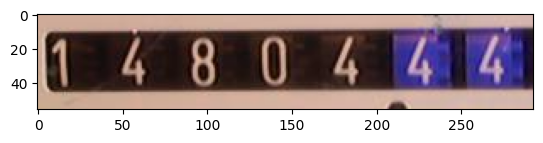

In [12]:
org_img = cv2.imread('../data/temp_dataset/JPEGImages/00880000075276_0.jpg')
image = cv2.imread('../data/temp_dataset/annotation/00880000075276_0.jpg')

# Convert image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define lower and upper bounds of red color in HSV color space
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])
mask1 = cv2.inRange(hsv, lower_red, upper_red)

lower_red = np.array([170, 50, 50])
upper_red = np.array([180, 255, 255])
mask2 = cv2.inRange(hsv, lower_red, upper_red)

# Combine masks
mask = cv2.bitwise_or(mask1, mask2)

# Find contours
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the largest contour and draw a bounding box around it
if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    print("Bounding boxes: ", x,y,w,h)

crop_img = org_img[y:y+h, x:x+w]
plt.imshow(crop_img)
plt.show()


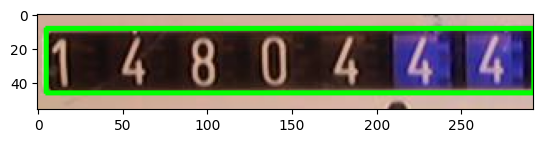

In [13]:
# Load the image and convert to grayscale
img = crop_img
import cv2

# Load the image and convert to grayscale
img = cv2.imread('digits.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply a threshold to create a binary image
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

# Find contours in the binary image
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Loop through the contours and filter out any small or non-rectangular contours
for contour in contours:
    if cv2.contourArea(contour) < 50:
        continue
    x, y, w, h = cv2.boundingRect(contour)
    if w / h < 0.5:
        continue

    # Extract the region of interest corresponding to the current contour
    digit_roi = thresh[y:y+h, x:x+w]

    # Resize the ROI to a fixed size (e.g., 28x28)
    digit_roi = cv2.resize(digit_roi, (28, 28))

    # Draw a rectangle around the bounding box
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Show the final image with bounding boxes
plt.imshow(img)
